<a href="https://colab.research.google.com/github/Jeremy-su1/VLMs/blob/main/CLIP_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision-Language Models of the Multi-Modal
## **CLIP**

## Review of CLIP paper

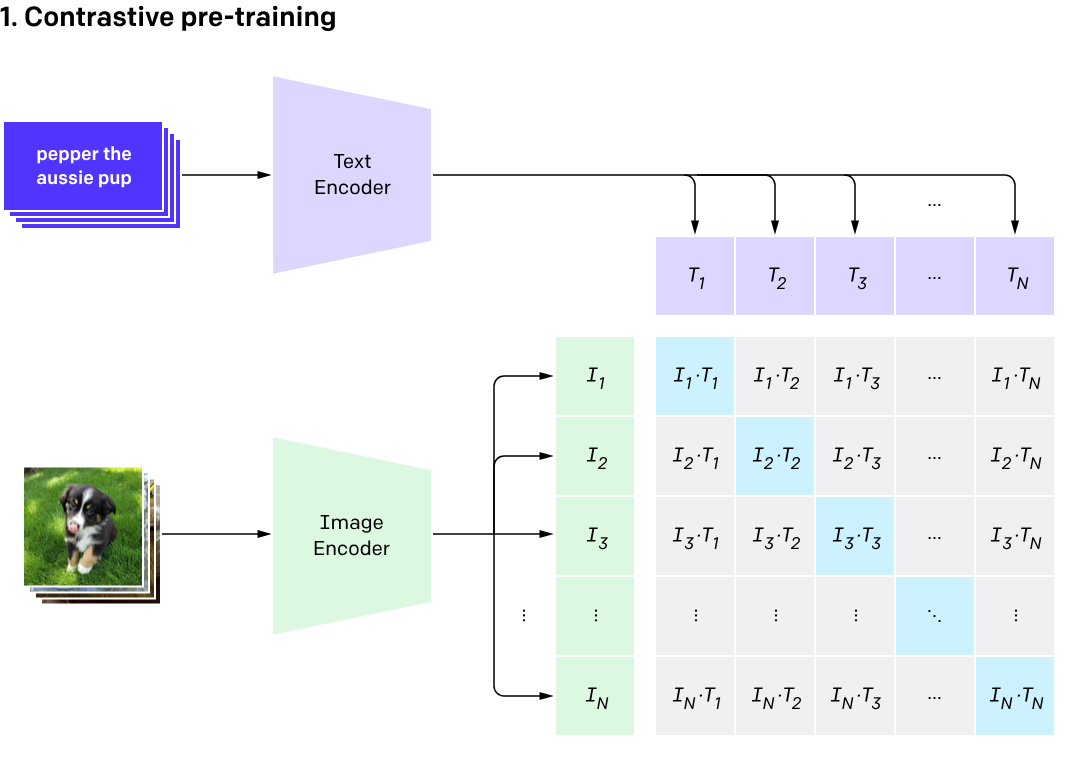

https://openai.com/index/clip/


## **CLIP.ipynb 실습 목적 및 전체 코드 흐름**
*코드 실습 목적*
- CLIP 모델 동작 구조 이해
- zero-shot transfer 방식 확인
- Prompt가 곧 분류기

*코드 흐름*
1. 환경 설정 및 라이브러리 설치  
  . CLIP모델을 Github에서 설치하고, 필요한 라이브러리(Pytorch, clip, PIL, matplotlib 등)를 load  
  . GPU 확인
2. Dataset 준비  
  . 두 개의 샘플 Image를 다운로드하여 리스트로 저장  
  . example text prompt(class label)를 정의  
3. CLIP 모델 불러오기  
  . 사전 학습된 ViT-B/32 모델과 해당 전처리 함수를 로드  
4. 전처리 및 임베딩 추출  
  . Image는 CLIP 전처리(preprocess)를 적용하여 tensor로 변환하고, text는 tokenize를 사용  
5. Cosine 유사도 계산 및 예측  
  . Image & Text Embedding간의 내적을 계산하여 유사도(logits)를 구한 후, softmax로 확률 분포를 생성  
  . 각 Image에 대해 가장 높은 확률을 가진 text prompt 예측  
6. 결과 시각화  
  . 각 Image와 함께 예측 결과(Class 및 확률)를 시각적으로 출력  
  . Image-Text 유사도 행렬을 히트맵 형태로도 시각화  
7. [확장] Prompt Engineering   
  . 기존 prompt 외에도 다양한 변형 프롬프트를 추가하여 동일 Image에 대해 예측 결과 비교  


# Section 1. Install the python Library

In [1]:
#@title ##1-1.Check the Python version in colab
# import the sys module
# sys 모듈은 파이썬 인터프리터와 관련된 함수와 변수들을 제공
import sys

# 현재 파이썬 인터프리터의 버전 정보를 출력
sys.version


'3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]'

In [2]:
# Google Drive approach
# Durations: 20s
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#@title ##1-2. Install the python library
# Durations: 1 minutes

# CLIP library를 GitHub에서 직접 설치
%pip install git+https://github.com/openai/CLIP.git

# OS 및 파일 경로 관련 모듈
import os
from pathlib import Path

# 난수 고정 및 수학 관련 (random)
import random
import math
import json

# PyTorch library: 딥러닝 모델 구축과 학습을 위한 library
import torch

# CLIP library: CLIP 모델과 관련 함수 제공
import clip

# PIL(Python Imaging Library): 이미지 처리 library
from PIL import Image

# requests: URL을 통해 데이터를 가져오기 위한 HTTP library
import requests

# BytesIO: 바이트 데이터를 파일 객체처럼 다룰 수 있게 해주는 모듈 (이미지 다운로드 후 처리에 사용)
from io import BytesIO

# matplotlib: 데이터 시각화를 위한 library
import matplotlib.pyplot as plt

# numpy: 수치 계산 및 배열 조작을 위한 library
import numpy as np

from tqdm import tqdm

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-lnkkcqcn
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-lnkkcqcn
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done


참고 사항
```python
%pip install git+https://github.com/openai/CLIP.git
```
VS.
```python
from transformers import CLIPProcessor, CLIPModel
```
OpenAI 공식 CLIP 라이브러리 VS. HuggingFace Transformers의 CLIP
> OpenAI 공식 CLIP 라이브러리 (GitHub)  
> OpenAI에서 직접 개발한 원본 구현체로, CLIP 모델의 학습, 추론, 전처리 함수 등이 포함  
> 코드가 비교적 간결, 연구 목적이나 실험을 위해 모델 구조를 직접 수정 가능  
> 원본 구현체이기 때문에 논문에 나온 세부 구현 방식과 유사하게 동작  

> HuggingFace Transformers의 CLIP (CLIPProcessor, CLIPModel)  
> HuggingFace의 Transformers 라이브러리 내에 통합된 버전, 다양한 모델과 동일한 API로 CLIP사용   
> CLIPProcessor는 Image와 Text 전처리를 일관되게 처리해주며, CLIPModel은 모델 추론 및 임베딩 추출 기능을 제공  
> HuggingFace Hub와 연동하여 사전 학습된 모델 가중치를 load할 수 있고, 다른 모델과 함께 파이프라인으로 사용할 수 있음  
> https://huggingface.co/docs/transformers/main/en/model_doc/clip

*Summary*
두 library 모두 동일한 CLIP 모델을 기반으로 하지만, OpenAI library는 원본 구현체로 모델의 내부를 수정하고, 실습할 수 있도록 가능하게 한 것이고, Transformers library는 보다 통합된 API와 편리한 사용성을 제공하여 다양한 모델과 함께 활용할 수 있음.

In [4]:
# 실습에서 매번 동일한 결과를 얻기 위해 랜덤 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [5]:
# 현재 Colab에서 GPU 사용 여부 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [6]:
ROOT = Path("/content")
IMG_DIR = ROOT/"clip_images"
CACHE_DIR = ROOT/"clip_cache"
IMG_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)
# clip_images: 인터넷에서 받은 이미지 저장
# clip_cache: 계산된 image embedding 저장

# Section 2. Load the CLIP Model

*Load model*
ViT-B/32: Vision Transformer(ViT) 기반으로, 32*32 패치 크기를 사용  

*clip.load function*  
clip.load는 2가지 값을 반환  
- 모델 객체(model): Image encoder와 Text encoder를 모두 포함한 CLIP 모델
- 전처리 함수(preprocess): 모델에 입력되는 이미지를 모델이 요구하는 형식으로 변환하는 function. 즉, Image resize, normalization, central crop 등의 작업을 수행



*Model Training and Evaluation*  
PyTorch 모델은 2가지 주요 모드를 제공(train, eval)  
1. Train Mode(model.train())  
- 목적: 모델을 학습(Training) 상태로 설정
- 특징:
  - 드롭아웃(Dropout): 일부 뉴런을 임의로 비활성화하여 과적합(overfitting)을 방지
  - 배치 정규화(Batch Normalization): 미니배치의 통계값(평균, 분산)을 사용하여 정규화
- 사용 시점: 모델을 학습할 때, 가중치 업데이트 전 과정에서 사용

2. Eval mode(model.eval())
- 목적: 모델을 평가(Evaluation) 상태로 설정
- 특징:
  - 드롭아웃 비활성화: 모든 뉴런이 활성화되어 결정론적(deterministic) 출력을 제공합니다.
  - 배치 정규화: 학습 중에 계산된 이동 평균(전역 통계)을 사용하여 정규화
- 사용 시점: 모델 추론(Inference)이나 테스트 단계에서 사용

In [7]:
#@title ## 2-1. load the clip model(encoder)

# Load the pre-trained CLIP model (ViT-B/32) along with its preprocessing function,
# which in cludes both the image encoder and the text encoder
#model, preprocess = clip.load("ViT-B/32", device=device)
model_name = "ViT-L/14"
model, preprocess = clip.load("ViT-L/14", device=device)
model = model.float()
# Set the model to evaluation mode to disable dropout and other training-specific behaviors.
model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)


ViT-B/32: Vision Transformer Base 크기 + 32×32 패치로 이미지를 토큰화  
ViT-L/14: Vision Transformer Large 크기 + 14×14 패치로 토큰화
* 패치 크기가 클수록 한 이미지에서 만들어지는 패치(토큰) 수가 줄어서 더 빠르고 가볍다.
  즉, L/14는 토큰을 많이 쓰지만, Large모델이므로 Base보다 정확도/검색 품질이 더 좋고 GPU를 더 많이 쓴다.

In [8]:
print("Model loaded:", "ViT-L/14")
print(model)
#print(model.visual)

Model loaded: ViT-L/14
CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_fea

In [9]:
print(type(model.visual))
print(dir(model.visual))

print("text_projection:", model.text_projection.shape)
print("visual_projection:", model.visual.proj)

<class 'clip.model.VisionTransformer'>
['T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_impl', '_compiled_call_impl', '_forward_hooks', '_forward_hooks_always_called', '_forward_hooks_with_kwargs', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_name', '_is_full_backward_hook', '_load_from_state_dict', '_load_state_dict_post_hooks', '_load_state_dict_pre_hooks', '_maybe_warn_non_full_backward_hook', '_modules', '_named_members', '_non_persistent_buffers_set', '_paramete

## 🔎 OpenAI CLIP 모델 구조 이해하기

`print(model)` == "CLIP 내부 구조"

---

### 1️⃣ visual

- 이미지 인코더 (Vision Transformer 또는 ResNet)
- 입력: 이미지
- 출력: 이미지 임베딩 벡터

👉 이미지를 고정된 차원의 벡터 공간으로 변환

---

### 2️⃣ transformer

- 텍스트 인코더 (Transformer 기반)
- 입력: 토큰화된 문장
- 출력: 텍스트 임베딩 벡터

👉 문장을 이미지와 동일한 의미 공간으로 매핑

---

### 3️⃣ projection (text_projection / visual.proj 등)

- 두 인코더의 출력을 같은 차원으로 맞추는 선형 변환
- 최종적으로 **공통(shared) embedding space**를 만듬

👉 CLIP의 핵심은 "두 모달리티를 같은 공간에 정렬(Alignment)" 하는 것.

---

### 4️⃣ logit_scale

- 유사도(similarity)에 곱해지는 학습 가능한 스케일 값
- Temperature 역할을 수행
- softmax 분포를 더 날카롭게(sharpen) 만듬.

👉 학습 시 image-text 정답 쌍을 더 확실하게 구분하도록 도와줌.

---

## 📌 정리

CLIP 구조
<pre>
Image → Image Encoder → Projection →  
                                     ↘  
                                       Shared Embedding Space → Similarity  
                                     ↗  
Text  → Text Encoder  → Projection →
</pre>

In [10]:
#@title ## 2-2. model diagram
%pip install torchinfo

from torchinfo import summary

model.visual = model.visual.float()

summary(model.visual, input_size=(1,3,224,224))
# input_size(batch size, channel, height, width)
# batch size: 한 번에 하나의 이미지가 입력된다는 의미
# channel: RGB
# image size : height, width

Layer (type:depth-idx)                        Output Shape              Param #
VisionTransformer                             [1, 768]                  1,050,624
├─Conv2d: 1-1                                 [1, 1024, 16, 16]         602,112
├─LayerNorm: 1-2                              [1, 257, 1024]            2,048
├─Transformer: 1-3                            [257, 1, 1024]            --
│    └─Sequential: 2-1                        [257, 1, 1024]            --
│    │    └─ResidualAttentionBlock: 3-1       [257, 1, 1024]            12,596,224
│    │    └─ResidualAttentionBlock: 3-2       [257, 1, 1024]            12,596,224
│    │    └─ResidualAttentionBlock: 3-3       [257, 1, 1024]            12,596,224
│    │    └─ResidualAttentionBlock: 3-4       [257, 1, 1024]            12,596,224
│    │    └─ResidualAttentionBlock: 3-5       [257, 1, 1024]            12,596,224
│    │    └─ResidualAttentionBlock: 3-6       [257, 1, 1024]            12,596,224
│    │    └─ResidualAttentionBlo

# Section 3. Prepare Images Dataset

In [11]:
#@title ## 3-1. Image load function
# Download util
def safe_name(i, url):
    ext = url.split("?")[0].split(".")[-1].lower()
    if ext not in ["jpg", "jpeg", "png", "webp"]:
        ext = "jpg"
    return f"img_{i:02d}.{ext}"

def download(url, out_path, timeout=15):
    if out_path.exists():
        return True
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        out_path.write_bytes(r.content)
        return True
    except Exception as e:
        print("download failed:", url, "->", e)
        return False

In [12]:
image_urls = [
    # cat / dog
    "https://images.unsplash.com/photo-1518791841217-8f162f1e1131?w=800",
    "https://images.unsplash.com/photo-1517849845537-4d257902454a?w=800",
    # car / airplane
    "https://images.unsplash.com/photo-1503376780353-7e6692767b70?w=800",
    "https://images.unsplash.com/photo-1529070538774-1843cb3265df?w=800",
    # pizza / laptop
    "https://upload.wikimedia.org/wikipedia/commons/d/d3/Supreme_pizza.jpg",
    "https://images.unsplash.com/photo-1515879218367-8466d910aaa4?w=800",
    # bicycle / flower
    "https://images.unsplash.com/photo-1518655048521-f130df041f66?w=800",
    "https://images.unsplash.com/photo-1501004318641-b39e6451bec6?w=800",
    # extra (장면 다양화)
    "https://images.unsplash.com/photo-1519681393784-d120267933ba?w=800",
    "https://images.unsplash.com/photo-1500530855697-b586d89ba3ee?w=800",
]

paths = []
for i, url in enumerate(tqdm(image_urls)):
    p = IMG_DIR / safe_name(i, url)
    if download(url, p):
        paths.append(p)

print("downloaded:", len(paths), "images")

100%|██████████| 10/10 [00:00<00:00, 515.43it/s]

download failed: https://upload.wikimedia.org/wikipedia/commons/d/d3/Supreme_pizza.jpg -> 403 Client Error: Forbidden for url: https://upload.wikimedia.org/wikipedia/commons/d/d3/Supreme_pizza.jpg
downloaded: 9 images


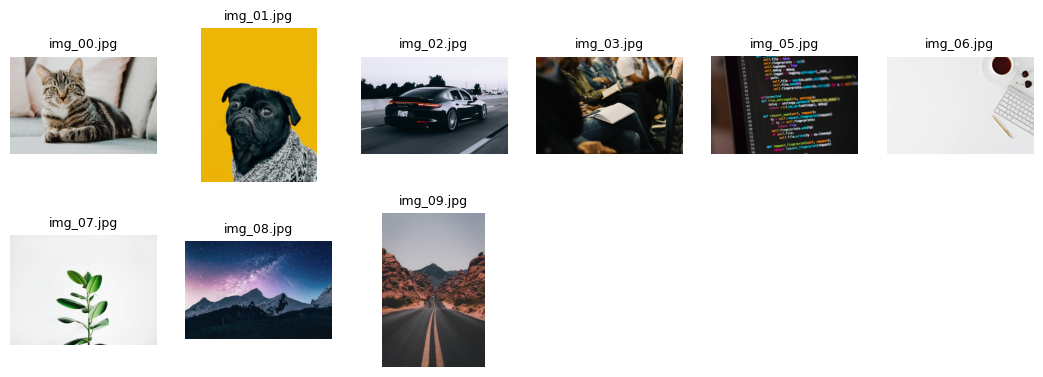

In [13]:
def show_grid(img_paths, ncols=6, size=2.2):
    n = len(img_paths)
    nrows = math.ceil(n / ncols)
    plt.figure(figsize=(ncols*size, nrows*size))
    for i, p in enumerate(img_paths):
        img = Image.open(p).convert("RGB")
        ax = plt.subplot(nrows, ncols, i+1)
        ax.imshow(img); ax.axis("off")
        ax.set_title(p.name, fontsize=9)
    plt.show()

show_grid(paths, ncols=6)

# Section 4. CLIP encode 과정

In [14]:
#@title ## 4-1. Image → Embedding 변환 과정

# 이미지 전처리: CLIP의 preprocess함수를 사용하여 이미지 변환
# CLIP의 이미지 처리 흐름:
# 1. 이미지를 모델 입력 형태(224×224, 정규화 등)로 변환
# 2. Vision Encoder 통과
# 3. 최종 feature 벡터 생성
# 4. L2 정규화 (cosine similarity 계산을 위해)

# 즉,
# Image → preprocess → Vision Encoder → feature → normalize

@torch.no_grad()
def encode_images(img_paths, batch_size=8):
    all_features = []

    for i in range(0, len(img_paths), batch_size):
        batch_paths = img_paths[i:i+batch_size]

        # 1️⃣ 이미지 로드 + RGB 변환
        images = [Image.open(p).convert("RGB") for p in batch_paths]
        # 2️⃣ CLIP 전용 전처리 (resize, center crop, normalize 등)
        image_input = torch.stack([preprocess(img) for img in images]).to(device)
        # Pass the preprocessed images through the image encoder.
        # Returns a tensor of shape [n, d_i] where n is the number of images
        # and d_i is the dimensionality of the image embeddings.
        # 3️⃣ Vision Encoder 통과
        image_features = model.encode_image(image_input)

        # 4️⃣ L2 정규화 (cosine similarity를 위해)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        all_features.append(image_features.float().cpu())

    return torch.cat(all_features, dim=0)


```python
[preprocess(img) for img in images
```
- preprocess 함수는 CLIP 모델을 로드할 때 함께 반환된 함수, CLIP에 적합한 방식으로 이미지를 전처리
  - 이미지의 크기를 조정, 중앙 크롭, 정규화 등 필요한 변환을 수행하여 모델이 기대하는 형태(보통 PyTorch 텐서, 특정 크기와 정규화된 픽셀 값)로 저장

```python
torch.stack
```
- torch.stack은 리스트에 있는 여러 텐서를 하나의 새로운 텐서로 결합
- 전처리된 이미지 텐서는 보통 [C,H,W] 형태를 지님 -> 이들을 stack하면 [N,C,H,W] 형태의 배치 텐서가 생성

*Summary*
- 목적: 여러 개의 이미지(리스트 형태)를 전처리하여 각각 tensor로 변환하고, 이를 하나의 배치 tensor로 결합 한후, 모델이 사용 가능한 device로 이동
- 결과: preprocessed_images 변수에는 [N,C,H,W]형태의 tensor가 저장. 이는 CLIP의 이미지 encoder에 바로 입력할 수 있는 형태가 됨.


```python
torch.no_grad()
```
- train mode가 아닌 eval 단계에서는 gradient 계산이 필요없음


image_features
```
model.encode_image(image_input)
```
위 호출을 통해 전처리된 이미지 배치를 이미지 인코더에 통과시켜 임베딩 벡터를 생성.  
[n,d_i] 형태의 텐서로 return된다(n: 이미지 개수, d_i: 이미지 임베딩 차원)

In [15]:
#@title ## 4-2. Text → Embedding 변환 과정

# CLIP의 텍스트 처리 흐름:
# 1. 문장을 tokenize
# 2. Text Transformer 통과
# 3. 최종 feature 벡터 생성
# 4. L2 정규화

# 즉,
# Text → tokenize → Text Encoder → feature → normalize

@torch.no_grad()
def encode_texts(texts, batch_size=64):

    all_features = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        # 1️⃣ 토큰화 (CLIP 전용 tokenizer)
        text_tokens = clip.tokenize(batch_texts).to(device)

        # 2️⃣ Text Transformer 통과
        text_features = model.encode_text(text_tokens)

        # 3️⃣ L2 정규화
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        all_features.append(text_features.float().cpu())

    return torch.cat(all_features, dim=0)

text_features
```
model.encode_text(text_tokens)
```
호출을 통해 토큰화된 텍스트 데이터를 텍스트 인코더에 입력하여 임베딩 벡터를 생성.  
[num_prompts, d_t] 형태의 텐서로 return된다(num_prompts: 텍스트 프롬프트의 개수, d_t: 텍스트 임베딩의 차원)


image_features와 text_features를 L2 normalization하여 벡터의 크기를 1로 맞추는 과정
```
.norm(dim=-1, keepdim=True)
```
마지막 차원(dim=-1)을 따라서 벡터의 L2 norm을 계산
keepdim 옵션은 연산 후에도 차원 수를 유지하여 broadcast 연산이 가능하도록 함.  
 * norm에 대한 이론: https://jeremy-su1.github.io/ml/deeplearning/nlp/norm/
  
임베딩 벡터를 norm으로 나누면, 모든 벡터가 크기 1을 가지게 되며 방향에 대한 정보만 남게 됨.
이렇게 정규화된 벡터끼리 cosine similarity를 계산하면, 두 벡터 간의 방향 차이만 반영되므로 내적이 곧 cosine similarity가 됨
**cosine similarity를 활용하는 CLIP의 contrastive learning이나 reranking 과정에서, 이 L2 normalization는 서로 다른 길이의 벡터가 크기 차이 때문에 영향을 받지 않도록 보장해줌.**

# Section 5. Similarity 계산

CLIP은 이미지와 텍스트를 같은 임베딩 공간에 정렬

정규화된 벡터이므로:

cosine similarity = dot product

Similarity Matrix 구조:

- image_feats: (N_images, D)
- text_feats:  (N_texts, D)

Similarity = image_feats @ text_feats.T
→ (N_images, N_texts)

In [16]:
def sim_matrix(image_feats, text_feats, use_logit_scale=False):
    """
    Compute image-text similarity matrix for CLIP.

    Args:
        image_feats: torch.Tensor, shape [n, d]
            - n: number of images
            - d: embedding dimension (e.g., 512)
            - expected to be L2-normalized (||x||=1), so dot product = cosine similarity
        text_feats: torch.Tensor, shape [m, d]
            - m: number of text prompts
            - expected to be L2-normalized
        use_logit_scale: bool
            - False: return pure cosine similarity matrix
            - True : return scaled similarity (CLIP "logits" used in training)

    Returns:
        logits: torch.Tensor, shape [n, m]
            - logits[i, j] = similarity between i-th image and j-th text
            - if normalized: logits[i, j] = cos(theta_ij)
            - if scaled:     logits[i, j] = exp(logit_scale) * cos(theta_ij)
    """

    # 모델의 출력을 맞추기 위함 (float16 or float32)
    if text_feats.dtype != image_feats.dtype:
        text_feats = text_feats.to(dtype=image_feats.dtype)

    # -------------------------------------------------------
    # Cosine similarity matrix
    # -------------------------------------------------------
    # image_feats: [n, d]
    # text_feats : [m, d]
    # text_feats.T: [d, m]
    #
    # Result:
    #   logits = [n, d] @ [d, m] = [n, m]
    #
    # If both are L2-normalized, dot product equals cosine similarity:
    #   logits[i, j] = cos(theta_ij) in [-1, 1]
    logits = image_feats @ text_feats.T

    # Optional: logit_scale 적용 (CLIP 학습 시 사용된 temperature)
    if use_logit_scale:
        scale = model.logit_scale.exp().to(dtype=logits.dtype, device=logits.device)
        logits = logits * scale

    return logits

**정령된 임베딩 공간에서 "이미지-텍스트 유사도 행렬"을 만드는 코드!!**  
정규화된 이미지 임베딩(image_features)과 정규화된 텍스트 임베딩(text_features) 사이의 cosine similarity를 계산  
image_features의 크기 = [n,d] (n = 이미지 개수, d = 임베딩 차원)  
text_features의 크기 = [m,d] (m = 프롬프트/텍스트 개수, d = 임베딩 차원)  
text_features.T는 [d,m]형태이므로 Transpose한 뒤 연산을 수행하면, [n,m] 크기의 logit 행렬이 생성    
[n,m]의 logit 행렬이 주는 의미: **n번째의 이미지와 m번째 텍스트 간의 코사인 유사도를 나타냄**  
(Optional) `logit_scale`을 적용하면 cosine similarity에 **scale(=exp(logit_scale))**을 곱한 값이 되고, CLIP 학습에서 softmax로 contrastive loss를 계산할 때 사용된 "logits" 형태와 동일한 의미임.


logit_scale: softmax를 사용하여 sharper하게 만들어 정답 쌍을 더 강하게 구분하기 위함

logit_scale 행렬을 확률 분포로 변환하는 과정  
[softmax]   
![image.png](https://miro.medium.com/v2/resize:fit:960/format:webp/1*5nKWsukS6lPR-7fHtlK2Rg.png)

# Section 6. 결과 시각화 & Top-K Util


*3가지 유틸*

1) `plot_bar()`  
- 한 이미지(또는 한 쿼리)에 대해 클래스/문장별 유사도 점수를 막대그래프로 보여줌

2) `topk()`  
- similarity 점수에서 상위 K개 결과를 빠르게 뽑아옴.

3) `plot_heatmap()`  
- (이미지 × 쿼리), (템플릿 × 클래스) 같은 2D 유사도 행렬을 한 번에 보여줌  
- retrieval 구조를 "한 장의 그림"으로 이해할 때 가장 유용

In [17]:
#@title ## 6-1. plot_bar: 1D 점수 막대그래프
def plot_bar(names, scores, title, figsize=(8, 3), rotate=25):
    """
    1D scores를 막대그래프로 시각화하는 함수

    Args:
      names   : x축 라벨 리스트 (클래스명/문장/답변 후보 등)
      scores  : 각 라벨의 유사도 점수 (list/np.array)
      title   : 그래프 제목
      figsize : 그림 크기
      rotate  : x축 라벨 회전 각도
    """
    plt.figure(figsize=figsize)
    plt.bar(names, scores)
    plt.xticks(rotation=rotate, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [18]:
#@title ## 6-2. Top-K 결과 추출

#- Text-to-Image Retrieval: 문장 하나 → Top-5 이미지
#- Image-to-Text Retrieval: 이미지 하나 → Top-5 문장
# 그래서 similarity 점수 벡터에서 상위 K개 인덱스를 뽑는 `topk()`를 사용

def topk(scores_1d, k=5):
    """
    1D 텐서(scores_1d)에서 상위 K개 점수와 인덱스를 반환

    Args:
      scores_1d : torch.Tensor shape (N,)
      k         : top-k

    Returns:
      vals : numpy array of top-k scores
      idx  : numpy array of top-k indices
    """
    # 요청 k가 N보다 큰 경우를 방지
    k = min(k, scores_1d.numel())
    vals, idx = torch.topk(scores_1d, k=k)
    return vals.cpu().numpy(), idx.cpu().numpy()

In [19]:
#@title ## 6-3. Heatmap 시각화 (2D similarity를 한 눈에)

def plot_heatmap(M, xlabels, ylabels, title, figsize=(10, 5), annotate=False):
    """
    2D matrix(M)를 히트맵으로 시각화하는 함수

    Args:
      M        : torch.Tensor or np.array shape (R, C)
      xlabels  : 열 라벨 리스트 (queries / classes)
      ylabels  : 행 라벨 리스트 (images / templates)
      title    : 그래프 제목
      figsize  : 그림 크기
      annotate : 각 셀에 수치 표시 여부
    """
    # torch tensor면 numpy로 변환
    if hasattr(M, "cpu"):
        M = M.cpu().numpy()
    else:
        M = np.array(M)

    plt.figure(figsize=figsize)
    plt.imshow(M, aspect="auto")
    plt.colorbar()

    plt.xticks(range(len(xlabels)), xlabels, rotation=25, ha="right")
    plt.yticks(range(len(ylabels)), ylabels)
    plt.title(title)

    # 옵션: 각 셀에 숫자 표시 (행/열이 많으면 가독성 떨어질 수 있음)
    if annotate:
        r, c = M.shape
        for i in range(r):
            for j in range(c):
                plt.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

In [20]:
#  image embedding cache 사용하는 code
# ==================================
# 목적:
# - 이미지 임베딩 계산은 비용이 크므로
# - 한 번 계산한 결과를 파일로 저장
# - 이후 실습에서는 다시 계산하지 않고 불러오기
# ==================================

# 모델 이름에 따라 다름 cache 파일 사용
cache_path = CACHE_DIR / f"image_feats_{model_name.replace('/','_')}.pt"
if cache_path.exists():
    image_feats = torch.load(cache_path)
    print("loaded cache:", image_feats.shape)
else:
    print("computing image embeddings...")
    # encode_images() 호출 ➡️ Vision Encoder 통과
    image_feats = encode_images(paths)
    # 계산 결과를 파일로 저장
    torch.save(image_feats, cache_path)
    print("computed and saved embeddings")
    print("Shape:", image_feats.shape)
    print("Dtype:", image_feats.dtype)

loaded cache: torch.Size([9, 768])


🎯 Cache가 필요한 이유?
 - Clip에서 가장 무거운 연산은 encode_image()
    ➡️ 이미지 10장만 있어도 GPU에서 몇 초가 걸림
    여기에서는 prompt를 여러 번 바꿀 때마다 다시 계산을 하게 되면 비효율적이게 됨.
    즉, embedding공간에 대한 encoder연산을 매번하게 하지 않고 저장.
 -  torch.Size([9,768])
    ➡️ 9: 이미지 개수, 768: 모든 이미지를 768차원 의미 벡터로 변환

  ?? cache없이 매번 돌리면 얼마나 느려질까요??

# Mission 1) Zero-shot 분류를 위한 "텍스트 클래스 프롬프트" 만들기

In [21]:
# 1) 우리가 구분하고 싶은 클래스(카테고리) 목록
# - 여기서는 8개의 클래스로 간단한 분류를 나타냄
labels = ["cat","dog","car","airplane","pizza","laptop","bicycle","flower"]

# 2) CLIP에서 텍스트는 "분류기" 역할을 하므로
#    각 클래스를 prompt 형태로 정의
#    - 가장 기본적인 prompt 템플릿: "a photo of a {class}"
#    - {} 자리에 클래스명을 넣어서 각 클래스를 문장을 만듬
base_template = "a photo of a {}"

# 3) 클래스 labels들을 template에 넣어서 prompt리스트 생성
prompts = [base_template.format(c) for c in labels]
#print(prompts)

# 4) prompt들을 CLIP 텍스트 encoder에 넣어서 text embedding(text_feats)생성
#    - encode_texts 안에서:
#      (a) tokenize → (b) model.encode_text → (c) L2 정규화 수행
#    - 결과 shape: [prompt 개수, 임베딩 차원]
text_feats = encode_texts(prompts)
#print(text_feats.shape)

# 5) 이미지 임베딩(image_feats)과 텍스트 임베딩(text_feats)의 유사도 행렬(similarity matrix) 계산
# - image_feats shape: [N, D] (N=이미지 개수)
# - text_feats  shape: [C, D] (C=클래스/프롬프트 개수)
# - sim_matrix 결과 S shape: [N, C]
#
# 의미:
#   S[i, j] = i번째 이미지와 j번째 클래스 프롬프트의 cosine similarity
#   (이미 임베딩이 L2 정규화되어 있으므로 dot product = cosine similarity)
S = sim_matrix(image_feats, text_feats, use_logit_scale=False)  # (N, C)

# 6) shape 출력: "우리가 만든 것이 이미지×클래스 점수표"임을 확인
print("S:", S.shape)

S: torch.Size([9, 8])


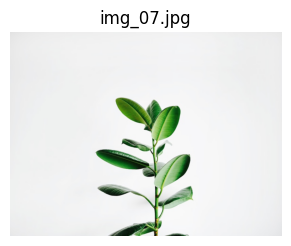

pred: flower


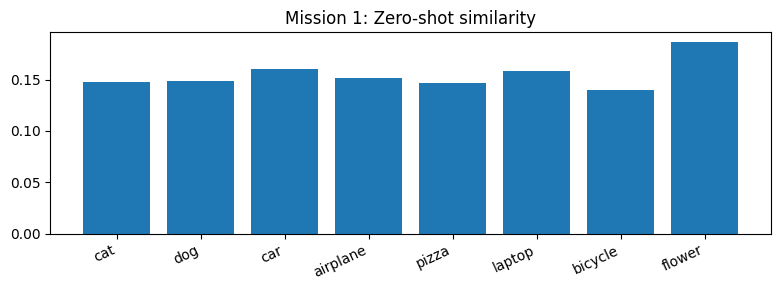

In [22]:
# idx_img: Image index로 변경하면서 테스트 해보기
idx_img = 6
img = Image.open(paths[idx_img]).convert("RGB")
plt.figure(figsize=(3.5,3.5)); plt.imshow(img); plt.axis("off"); plt.title(paths[idx_img].name); plt.show()

scores = S[idx_img].numpy()
pred = labels[int(np.argmax(scores))]
print("pred:", pred)
plot_bar(labels, scores, "Mission 1: Zero-shot similarity")

# Mission 2) "Prompt == 분류기"

template: a photo of a {}        -> pred: cat


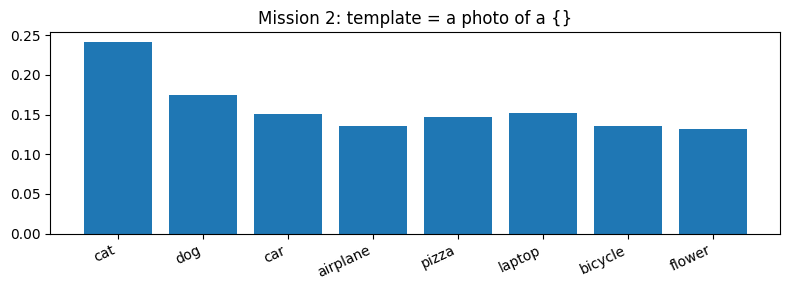

template: a close-up photo of a {} -> pred: cat


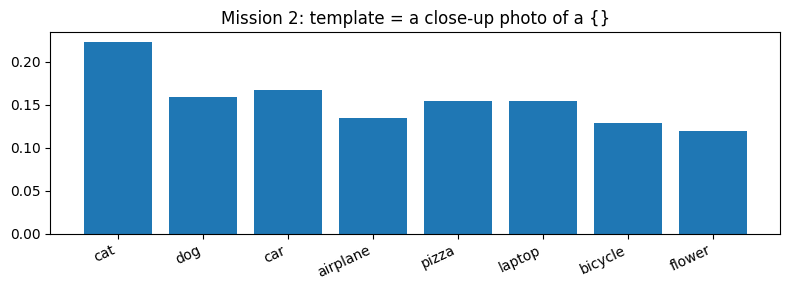

template: a blurry photo of a {} -> pred: cat


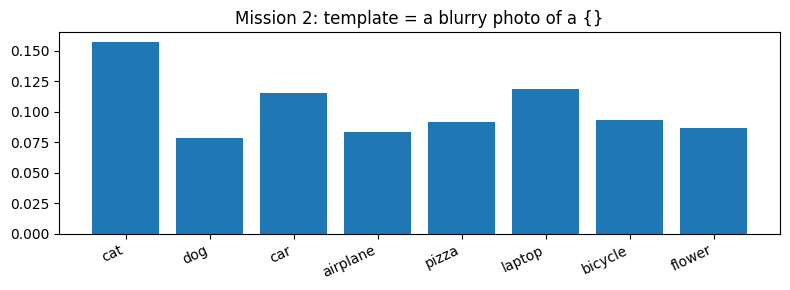

template: a sketch of a {}       -> pred: cat


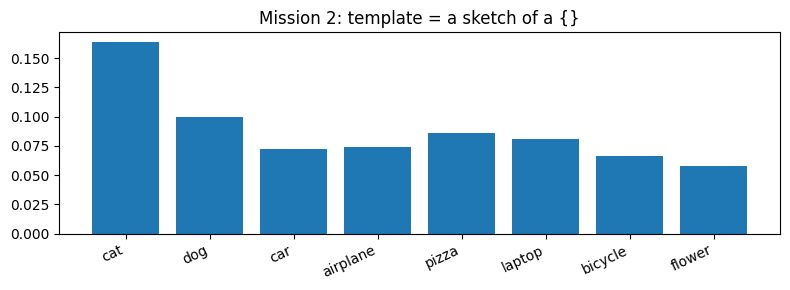

In [23]:
# 1) 템플릿 정의
# - 같은 클래스(labels)를 서로 다른 표현 방식으로 말해본다.
# - 예: "a photo of a cat" vs "a sketch of a cat"
# - 템플릿이 바뀌면 텍스트 인코더가 만든 임베딩이 달라진다.

templates = [
    "a photo of a {}",
    "a close-up photo of a {}",
    "a blurry photo of a {}",
    "a sketch of a {}",
]

# 2) 어느 이미지를 대상으로 볼지 선택
##  index 변경을 통해 여러 이미지에 대해 테스트 수행
idx_img = 0

# 3) 템플릿을 하나씩 바꿔가며 실험
for t in templates:

    # 3-1) 같은 labels를 현재 템플릿으로 문장(prompt) 리스트로 만듬
    # - labels: ["cat","dog",...]
    # - t_prompts 예시: ["a photo of a cat", "a photo of a dog", ...
    t_prompts = [t.format(c) for c in labels]
    t_feats = encode_texts(t_prompts)
    St = sim_matrix(image_feats, t_feats, use_logit_scale=False)

    scores = St[idx_img].numpy()
    pred = labels[int(np.argmax(scores))]
    print(f"template: {t:22s} -> pred: {pred}")
    plot_bar(labels, scores, f"Mission 2: template = {t}")

일반적인 분류 모델 ➡️ "Linear layer + softmax" 같은 "학습된 분류기 헤드"가 있음  
CLIP은 헤드가 없고, 대신:  
 → Class이름을 문장으로 만들고  
 → 그 문장 임베딩과 이미지 임베딩을 비교해서  
 → 가장 유사한 문장을 고르는 방식 (=zero-shot 분류)  

## Template × Class Heatmap

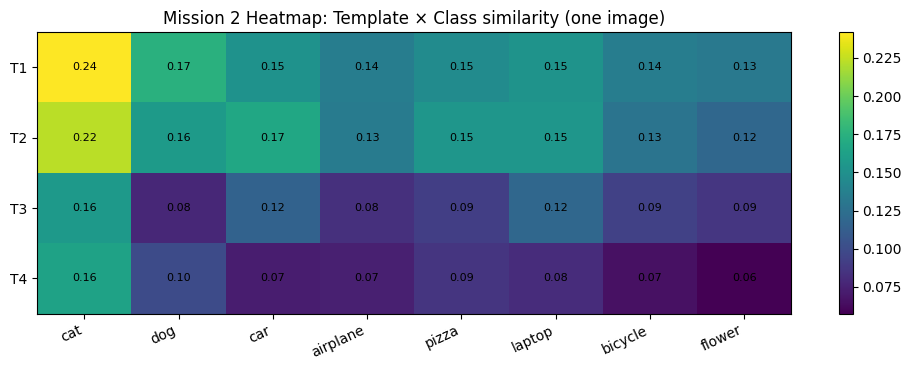

T1: a photo of a {}
T2: a close-up photo of a {}
T3: a blurry photo of a {}
T4: a sketch of a {}


In [24]:
# =========================================================
# 목적:
# - 템플릿을 여러 개 바꿨을 때, 매번 bar chart를 보면 비교가 어려움.
# - 한 장의 그림(heatmap)으로:
#   "템플릿이 바뀌면 어떤 클래스 점수가 올라가고 내려가는지"
#   를 전체적으로 보여줌.
#
# Heatmap의 구조:
# - 행(row): 템플릿 (T개)
# - 열(col): 클래스(labels) (C개)
# - 값(value): 특정 이미지(idx_img)에 대해, 템플릿-클래스 prompt의 cosine similarity
# =========================================================

# 1) 분석 대상 이미지
idx_img = 0

# 2) 각 템플릿에 대해 클래스 점수 벡터를 모은다.
# - rows에는 각 템플릿별 [C] 점수 벡터가 들어감
rows = []
row_names = []

for t in templates:
    # 2-1) 템플릿으로 클래스 프롬프트 만들기
    # 예: "a sketch of a cat", "a sketch of a dog", ...
    t_prompts = [t.format(c) for c in labels]
    t_feats = encode_texts(t_prompts)
    St = sim_matrix(image_feats, t_feats, use_logit_scale=False)
    # 2-2) 우리가 선택한 이미지(idx_img) 행만 뽑기 → [C]
    rows.append(St[idx_img].cpu())   # (C,)
    row_names.append(t)

# 3) 템플릿별 점수 벡터([C])를 쌓아서 2D 행렬로 만듬
# - H shape: [T, C]
# - H[r, c]는 r번째 템플릿, c번째 클래스에 대한 similarity 점수
H = torch.stack(rows, dim=0)         # (T, C)

# 4) Heatmap 시각화
# - x축: 클래스(labels)
# - y축: 템플릿(T1~Tn)
# - 색이 진할수록 유사도 점수가 높음
plot_heatmap(
    H,
    xlabels=labels,
    ylabels=[f"T{i+1}" for i in range(len(templates))],
    title="Mission 2 Heatmap: Template × Class similarity (one image)",
    figsize=(10,3.8),
    #annotate=False
    annotate=True
)
for i, t in enumerate(templates):
    print(f"T{i+1}: {t}")

## ★ my template 바꿔보기

my pred: dog


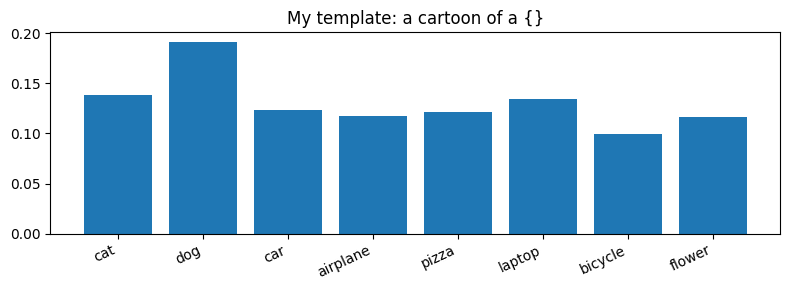

In [25]:
my_template = "a cartoon of a {}"
my_prompts = [my_template.format(c) for c in labels]
my_feats = encode_texts(my_prompts)
Sm = sim_matrix(image_feats, my_feats, use_logit_scale=False)

# idx_img 변경
idx_img=1
scores = Sm[idx_img].numpy()
pred = labels[int(np.argmax(scores))]
print("my pred:", pred)
plot_bar(labels, scores, f"My template: {my_template}")


# Mission 3) Text-to-Image Retrieval + Heatmap

Query: a photo of a dog | Top sims: [0.223 0.175 0.159 0.148 0.138]


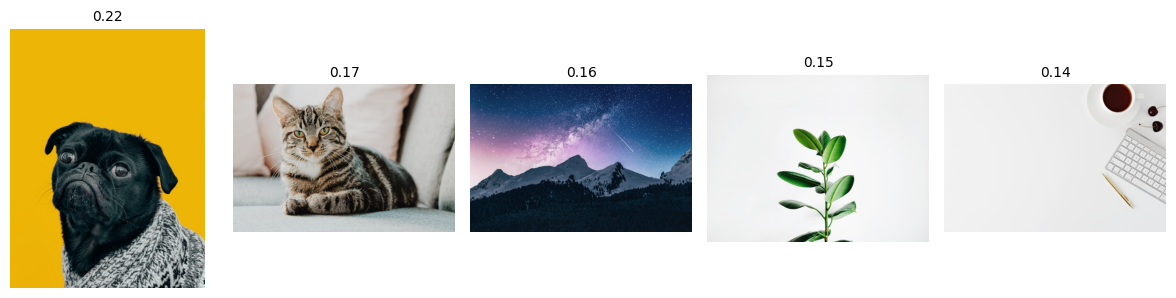

Query: a photo of a pizza | Top sims: [0.153 0.147 0.146 0.143 0.14 ]


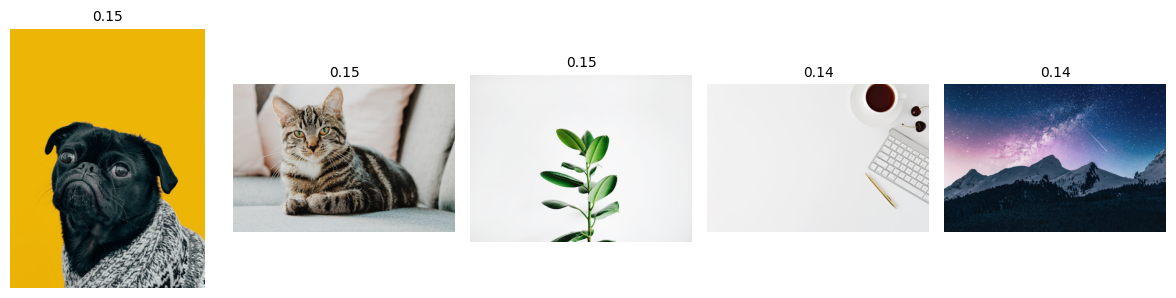

Query: a photo of an airplane | Top sims: [0.177 0.153 0.141 0.141 0.137]


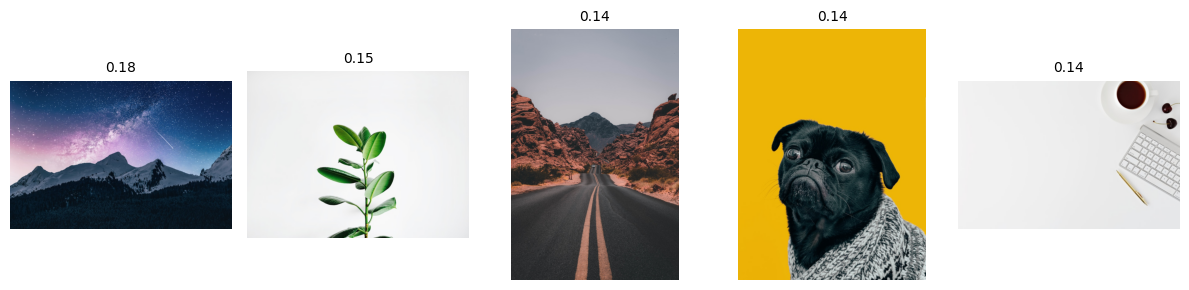

Query: a photo of a laptop | Top sims: [0.207 0.183 0.169 0.164 0.158]


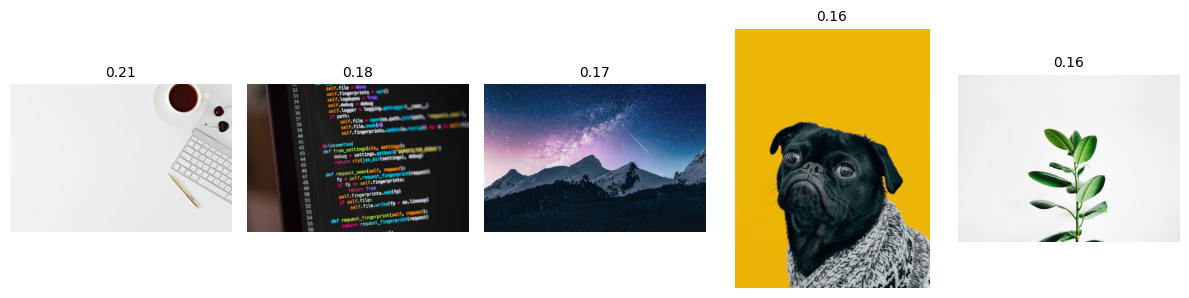

Query: a photo of a flower | Top sims: [0.187 0.147 0.139 0.135 0.132]


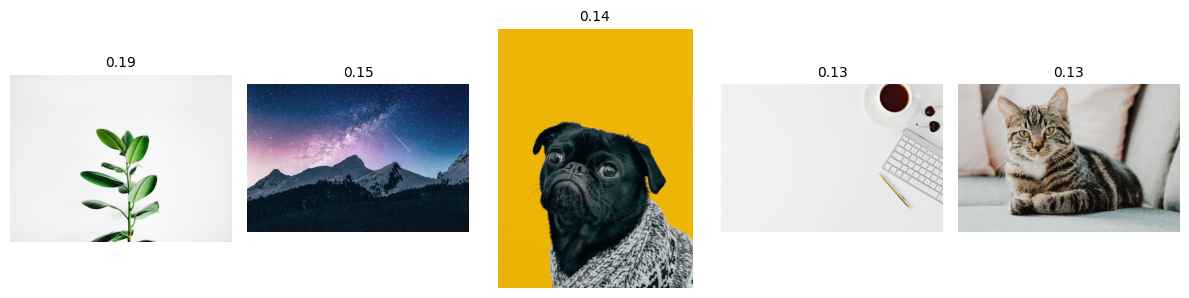

In [26]:
# =========================================================
# Text-to-Image Retrieval (텍스트로 이미지 찾기)
# =========================================================

# 1) Retrival에 사용할 텍스트 쿼리 정의
queries = [
    "a photo of a dog",
    "a photo of a pizza",
    "a photo of an airplane",
    "a photo of a laptop",
    "a photo of a flower",
]

# 2) 쿼리 임베딩 생성
# - q_feats shape: [Q, D]
# - encode_texts 내부에서 tokenize + encode_text + L2 normalize 수행
q_feats = encode_texts(queries)
R = sim_matrix(image_feats, q_feats, use_logit_scale=False)  # (N, Q)

# 3) 한 쿼리에 대해 top-k 이미지를 보여주는 함수 정의
def show_topk(query_idx, k=5):

    # (N,) 벡터: 모든 이미지 vs 특정 쿼리의 유사도 점수
    sims = R[:, query_idx]
    # topk()로 상위 k개 점수와 인덱스 가져오기
    vals, idx = topk(sims, k=k)
    # 점수 출력: 어떤 값들이 top으로 뽑혔는지 확인
    print("Query:", queries[query_idx], "| Top sims:", np.round(vals, 3))

    plt.figure(figsize=(12,3))
    for j, ii in enumerate(idx):
        im = Image.open(paths[int(ii)]).convert("RGB")
        ax = plt.subplot(1, len(idx), j+1)
        ax.imshow(im); ax.axis("off")
        ax.set_title(f"{vals[j]:.2f}", fontsize=10)
    plt.tight_layout()
    plt.show()

# 모든 쿼리 출력
for qi in range(len(queries)):
    show_topk(qi, k=5)

## Image × Query Heatmap

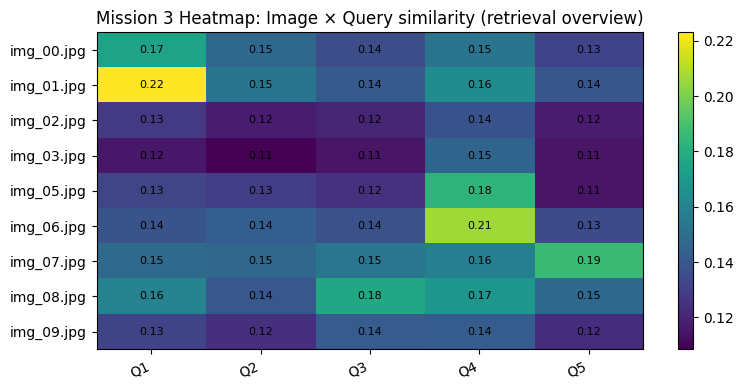

Q1: a photo of a dog
Q2: a photo of a pizza
Q3: a photo of an airplane
Q4: a photo of a laptop
Q5: a photo of a flower


In [27]:
img_names = [p.name for p in paths]

plot_heatmap(
    R,
    xlabels=[f"Q{i+1}" for i in range(len(queries))],
    ylabels=[n[:18] for n in img_names],
    title="Mission 3 Heatmap: Image × Query similarity (retrieval overview)",
    figsize=(8, max(4, len(paths)*0.35)),
    annotate=True
)
for i, q in enumerate(queries):
    print(f"Q{i+1}: {q}")

# Mission 4) CLIP으로 QA 흉내내기

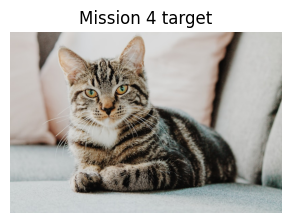

Question: What animal is shown in the image?
Predicted Answer: cat


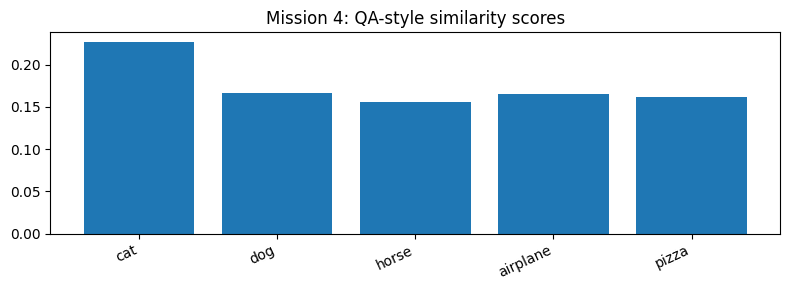

In [28]:
# =========================================================
# 핵심 아이디어:
# - CLIP은 생성 모델이 아님
# - 질문을 직접 이해해서 답을 생성하지 못함
#
# 대신
# 1) 질문을 텍스트로 만들고
# 2) 가능한 답변 후보들을 여러 개 텍스트로 만들고
# 3) 이미지와 "질문+답변 후보" 문장의 유사도를 비교해
# 4) 가장 점수가 높은 후보를 선택!!!
#
# 즉, 이것은 진짜 QA가 아니라
# !!! "후보 중 가장 이미지와 어울리는 문장 찾기"!!!!
# =========================================================

# 1️⃣ 테스트할 이미지 선택
idx_img = 0
img = Image.open(paths[idx_img]).convert("RGB")
plt.figure(figsize=(3.5,3.5)); plt.imshow(img); plt.axis("off"); plt.title("Mission 4 target"); plt.show()

# 2️⃣ 질문 정의
question = "What animal is shown in the image?"
#question = "How many objects are in the iamge?"

# 3️⃣ 가능한 답변 후보 정의
answer_candidates = ["cat", "dog", "horse", "airplane", "pizza"]

# 4️⃣ 질문 + 답변 후보를 하나의 문장으로 결합
# - "Question: ... Answer: cat" 형태
qa_prompts = [
    f"Question: {question} Answer: {a}"
    for a in answer_candidates
]

# 5️⃣ 텍스트 임베딩 생성
qa_feats = encode_texts(qa_prompts)

# 6️⃣ 해당 이미지의 임베딩 가져오기
img_feat = image_feats[idx_img].unsqueeze(0)  # [1, D]

# 7️⃣ 유사도 계산
S_qa = sim_matrix(img_feat, qa_feats, use_logit_scale=False)

# 8️⃣ 점수 벡터 추출
scores = S_qa[0].cpu().numpy()

# 9️⃣ 가장 점수가 높은 후보 선택
pred_idx = int(np.argmax(scores))
pred_answer = answer_candidates[pred_idx]

print("Question:", question)
print("Predicted Answer:", pred_answer)

# 🔟 점수 분포 시각화
plot_bar(answer_candidates, scores, "Mission 4: QA-style similarity scores")

# Section 7. meme Image 테스트

https://en.wikipedia.org/wiki/Italian_brainrot


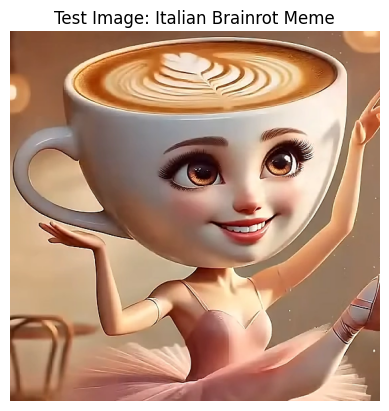

In [29]:
# Colab: OpenCV 설치 (한 번만 실행)
!pip -q install opencv-python-headless

import requests, numpy as np, cv2, matplotlib.pyplot as plt

# 기존 변수명 그대로 사용
#meme_url = "https://upload.wikimedia.org/wikipedia/commons/f/f6/Tralalero_Tralala.webp"
meme_url = "https://upload.wikimedia.org/wikipedia/commons/6/6c/Ballerina_Cappuccina.png"


# WebP를 확실히 받기 위한 헤더 포함
headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "image/webp,image/*,*/*;q=0.8",
}
response = requests.get(meme_url, headers=headers, timeout=15)
response.raise_for_status()

# OpenCV로 디코딩 → RGB로 변환 → meme_image 변수에 담기
buf = np.frombuffer(response.content, dtype=np.uint8)
decoded = cv2.imdecode(buf, cv2.IMREAD_UNCHANGED)
if decoded is None:
    raise RuntimeError("이미지 디코딩 실패: 응답이 이미지인지 확인 필요")

# 채널에 따라 RGB/RGBA 맞춰 변환
if decoded.ndim == 2:  # grayscale
    meme_image = cv2.cvtColor(decoded, cv2.COLOR_GRAY2RGB)
elif decoded.shape[2] == 4:  # BGRA
    meme_image = cv2.cvtColor(decoded, cv2.COLOR_BGRA2RGBA)
else:  # BGR
    meme_image = cv2.cvtColor(decoded, cv2.COLOR_BGR2RGB)

# 표시
plt.imshow(meme_image)
plt.axis("off")
plt.title("Test Image: Italian Brainrot Meme")
plt.show()


In [30]:
meme_texts = [
    "a photo of a ballerina in a cafe",
    "an Italian style AI-generated meme with espresso and fashion",
    "a chaotic collage of Italian stereotypes",
    "a surreal fashion editorial with coffee and neon signs"
]

In [31]:
from PIL import Image
import numpy as np

# meme_image: NumPy 배열 → PIL.Image(RGB)로 변환
if isinstance(meme_image, np.ndarray):
    meme_image = Image.fromarray(meme_image).convert("RGB")
elif isinstance(meme_image, Image.Image):
    meme_image = meme_image.convert("RGB")  # 혹시 RGBA 등일 때 대비
else:
    raise TypeError(f"Unexpected type for meme_image: {type(meme_image)}")


In [32]:
meme_image_input = preprocess(meme_image).unsqueeze(0).to(device)
meme_text_tokens = clip.tokenize(meme_texts).to(device)

In [33]:
with torch.no_grad():
    meme_image_features = model.encode_image(meme_image_input)
    meme_text_features = model.encode_text(meme_text_tokens)

    meme_image_features /= meme_image_features.norm(dim=-1, keepdim=True)
    meme_text_features /= meme_text_features.norm(dim=-1, keepdim=True)

    meme_similarity = (100.0 * meme_image_features @ meme_text_features.T).softmax(dim=-1)


In [34]:
# 결과 출력
print("\n🎭 Meme Image Prediction:")
for i, text in enumerate(meme_texts):
    print(f"{text:<40s}: {meme_similarity[0][i].item():.4f}")


🎭 Meme Image Prediction:
a photo of a ballerina in a cafe        : 0.9983
an Italian style AI-generated meme with espresso and fashion: 0.0017
a chaotic collage of Italian stereotypes: 0.0000
a surreal fashion editorial with coffee and neon signs: 0.0000
